# The classical anharmonic oscillator

The `AnharmonicOscillator` class of the Models module implements the classical model of the non-linear optical response of
R. W. Boyd, *Nonlinear Optics*, 4th ed. (2020), Section 1.4. The displacement $x$ of an electron bound to a nucleus obeys

$$\ddot{x} + 2\gamma\dot{x} + \omega_0^2 x + a x^2 - b x^3 = -E(t)$$

and the polarization is $P = -Nx$, where $N$ is the density of the oscillators. The quadratic term $a$ describes a
non-centrosymmetric medium and gives the second order response, the cubic term $b$ a centrosymmetric medium and gives the third
order one. Atomic units are used ($e = m = \hbar = 1$, the charge of the electron is $-1$) and $P = \chi E$.

The class provides two independent descriptions of the response:

1. **Numerical polarization** $P(t)$. The `solve` method integrates the complete equation of motion (no perturbative expansion) with
   a fourth order Runge-Kutta method, also for many fields at the same time. The `sine_response` method uses it for the field
   $E_0\sin(\omega(t-t_0))$ switched on at $t_0$ (optionally summed to a second sine-shaped field, the pump), the `delta_response`
   method for the field $E_0\delta(t-t_0)$ (a kick $\Delta v = -E_0$ of the velocity at $t_0$). Their results are stored in an object
   with the attributes of the `YamboNLDBParser` class, so they can be analyzed with the Optics module like the results of `yambo_nl`.
2. **Analytical susceptibilities**, obtained with the perturbative expansion $x = x^{(1)} + x^{(2)} + x^{(3)} + \dots$ of the equation
   of motion (Boyd, Eqs. (1.4.17), (1.4.24) and (1.4.52)). With $D(\omega) = \omega_0^2 - \omega^2 - 2i\omega\gamma$:

   * `chi1(w)` $= \chi^{(1)}(\omega) = N/D(\omega)$
   * `chi2(w1,w2)` $= \chi^{(2)}(\omega_1+\omega_2;\omega_1,\omega_2) = Na/[D(\omega_1+\omega_2)D(\omega_1)D(\omega_2)]$
   * `chi3(w1,w2,w3)` $= \chi^{(3)}(\omega_1+\omega_2+\omega_3;\omega_1,\omega_2,\omega_3) = Nb/[D(\omega_1+\omega_2+\omega_3)D(\omega_1)D(\omega_2)D(\omega_3)]$,
     only for $a = 0$ (otherwise the cascade of two second order processes gives a further third order term)

   The frequencies are signed (a negative frequency is associated to the complex conjugate field) and the susceptibilities are the
   ones of Boyd, without the degeneracy factor: the polarization at $\omega_1+\omega_2$ is $D\,\chi^{(2)}E(\omega_1)E(\omega_2)$, where
   $D$ is the number of distinct permutations of the frequencies (for instance $D = 2$ for $\omega_1 \neq \omega_2$).

In the Analysis_Optics notebook the numerical polarization is analyzed with the Optics module and the extracted susceptibilities are
compared with the analytical ones. Here we show the main features of the model.

In [1]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
from mppi.Models.AnharmonicOscillator import AnharmonicOscillator
from mppi.Optics.Utils import fit_sum_frequencies
from mppi.Utilities.Constants import HaToeV, FsToAu

print('Notebook executed on', datetime.datetime.now().strftime('%d/%m/%Y %H:%M'))

Notebook executed on 02/10/2026 18:22


## Linear susceptibility

Close to the resonance the imaginary part of $\chi^{(1)}(\omega)$ is a Lorentzian with full width at half maximum $2\gamma$

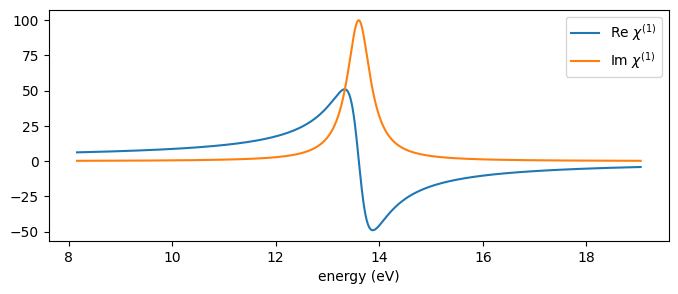

FWHM = 0.0196 Ha, 2*gamma = 0.0200 Ha


In [2]:
osc = AnharmonicOscillator(omega0=0.5, gamma=0.01) # Ha
w = np.linspace(0.3, 0.7, 1001)
chi1 = osc.chi1(w)

plt.figure(figsize=(8, 3))
plt.plot(w*HaToeV, chi1.real, label=r'Re $\chi^{(1)}$')
plt.plot(w*HaToeV, chi1.imag, label=r'Im $\chi^{(1)}$')
plt.xlabel('energy (eV)')
plt.legend()
plt.show()

half = w[chi1.imag > chi1.imag.max()/2]
print('FWHM = %.4f Ha, 2*gamma = %.4f Ha' % (half[-1]-half[0], 2*osc.gamma))

## Response to a monochromatic field

The numerical polarization induced by $E_0\sin(\omega t)$ is the sum of the steady state, which oscillates at the frequency of the
field and is given by the susceptibilities, and of a transient, generated by the switch on of the field. The transient oscillates at
the resonance frequency and decays as $e^{-\gamma t}$, so the steady state (used to extract the susceptibilities) is reached after
some multiples of $1/\gamma$: the Optics module warns if the fit starts before $12/\gamma$. Here the field is detuned from the
resonance, so the beating between the two components is visible. In the linear regime the steady state is
$P(t) = \chi^{(1)}(\omega)E(\omega)e^{-i\omega t} + c.c.$, with $E(\omega) = iE_0/2$

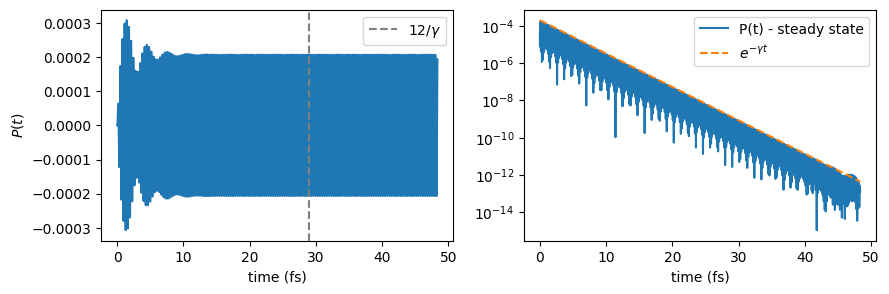

In [3]:
w0, E0 = 0.45, 1e-5
time = np.arange(0, 2000, 0.25) # au
data = osc.sine_response(time, [w0], amplitude=E0)
pol = data.Polarization[0][0]
steady = 2*(osc.chi1(w0)*0.5j*E0*np.exp(-1j*w0*time)).real

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(data.get_time(), pol)
axes[0].axvline(12/osc.gamma/FsToAu, color='gray', ls='--', label=r'$12/\gamma$')
axes[0].set_xlabel('time (fs)')
axes[0].set_ylabel('$P(t)$')
axes[0].legend()
axes[1].semilogy(data.get_time(), np.abs(pol-steady), label='P(t) - steady state')
axes[1].semilogy(data.get_time(), E0*np.abs(osc.chi1(w0))*np.exp(-osc.gamma*time), '--', label=r'$e^{-\gamma t}$')
axes[1].set_xlabel('time (fs)')
axes[1].legend()
plt.show()

## Harmonics and inversion symmetry

The spectrum of the steady state numerical polarization shows the harmonics generated by the non-linear terms (Boyd, Fig. 1.5.2).
The non-centrosymmetric oscillator ($a \neq 0$) produces both even and odd harmonics, and a static polarization (optical
rectification). The centrosymmetric one ($b \neq 0$) is invariant under $x \to -x$, $E \to -E$, so $P[-E] = -P[E]$ and only the odd
harmonics are present. A large field is used to make the higher harmonics visible

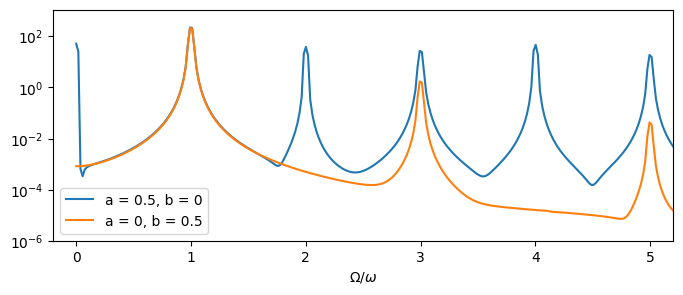

In [4]:
w0 = 0.12 # Ha, far from the resonances
time = np.arange(0, 4000, 0.25)
steady = time > 12/osc.gamma

plt.figure(figsize=(8, 3))
for o, label in [(AnharmonicOscillator(omega0=0.5, gamma=0.01, a=0.5), 'a = 0.5, b = 0'),
                 (AnharmonicOscillator(omega0=0.5, gamma=0.01, b=0.5), 'a = 0, b = 0.5')]:
    p = o.sine_response(time, [w0], amplitude=2e-2, substeps=4).Polarization[0][0][steady]
    spectrum = np.abs(np.fft.rfft(p*np.hanning(len(p))))
    freqs = 2*np.pi*np.fft.rfftfreq(len(p), d=time[1]-time[0])
    plt.semilogy(freqs/w0, spectrum, label=label)
plt.xlim(-0.2, 5.2)
plt.ylim(1e-6, None)
plt.xlabel(r'$\Omega/\omega$')
plt.legend()
plt.show()

## Harmonics from the analytical susceptibilities

In the perturbative regime the components of the polarization are given by the analytical susceptibilities:

* $P(\omega) = \chi^{(1)}(\omega)E(\omega)$
* $P(0) = 2\chi^{(2)}(0;\omega,-\omega)|E(\omega)|^2$ (optical rectification, $D = 2$)
* $P(2\omega) = \chi^{(2)}(2\omega;\omega,\omega)E(\omega)^2$
* $P(3\omega) = \chi^{(3)}(3\omega;\omega,\omega,\omega)E(\omega)^3$

with $|E(\omega)| = E_0/2$. These values are compared with the components of the numerical polarization, obtained by fitting its
steady state with a sum of harmonics (the `fit_sum_frequencies` function of the Optics module, the sine of amplitude $A$ has
$|P| = A/2$). For the centrosymmetric oscillator $\chi^{(2)} \propto a$ vanishes, in agreement with the inversion symmetry, and the
even components of the numerical polarization are zero within the accuracy of the integration. For the non-centrosymmetric oscillator
the third harmonic is generated by the cascade of two second order processes, not described by `chi3` (n.a. in the table)

In [5]:
w0, E0 = 0.12, 1e-3
Ew = E0/2
time = np.arange(0, 3000, 0.25)
steady = time > 12/osc.gamma

for o, label in [(AnharmonicOscillator(omega0=0.5, gamma=0.01, a=0.5), 'non-centrosymmetric (a = 0.5)'),
                 (AnharmonicOscillator(omega0=0.5, gamma=0.01, b=0.5), 'centrosymmetric (b = 0.5)')]:
    p = o.sine_response(time, [w0], amplitude=E0, substeps=4).Polarization[0][0]
    res, B0, _ = fit_sum_frequencies(time[steady], p[steady], {1: w0, 2: 2*w0, 3: 3*w0})
    numerical = {0: abs(B0), 1: res[1]['A']/2, 2: res[2]['A']/2, 3: res[3]['A']/2}
    analytical = {0: abs(2*o.chi2(w0, -w0))*Ew**2, 1: abs(o.chi1(w0))*Ew, 2: abs(o.chi2(w0, w0))*Ew**2,
                  3: abs(o.chi3(w0, w0, w0))*Ew**3 if o.a == 0 else None}
    print(label)
    print('   harmonic    |P| numerical    |P| analytical')
    for n in range(4):
        an = 'n.a.' if analytical[n] is None else '%.4e' % analytical[n]
        print('   %5d        %.4e       %s' % (n, numerical[n], an))

non-centrosymmetric (a = 0.5)
   harmonic    |P| numerical    |P| analytical
       0        1.8020e-05       1.8014e-05
       1        2.1224e-03       2.1221e-03
       2        1.1706e-05       1.1700e-05
       3        2.0645e-07       n.a.


centrosymmetric (b = 0.5)
   harmonic    |P| numerical    |P| analytical
       0        6.7900e-12       0.0000e+00
       1        2.1222e-03       2.1221e-03
       2        8.8400e-12       0.0000e+00
       3        3.9639e-08       3.9617e-08


## Validity of the perturbative regime

The analytical susceptibilities describe the numerical polarization only for small fields, where the $n$-th harmonic scales as
$E_0^n$. For larger fields the higher order terms of the expansion become important (for instance a term $\propto E_0^4$ also
contributes to the second harmonic) and the response cannot be described by a single susceptibility. This sets the range of fields that
can be used to extract the susceptibilities from a real-time computation, as the ones of `yambo_nl`: the field must be large enough
to make the non-linear signal visible but small enough to keep the response perturbative.

The equation of motion is solved for several amplitudes $E_0$ at the same time with the `solve` method, which receives a function of the
time that returns the field of each run, and the amplitudes of the first two harmonics are compared with the perturbative ones.
For fields larger than about $10^{-2}$ au the electron escapes from the potential well (the cubic potential has a barrier at
$x = \omega_0^2/a$)

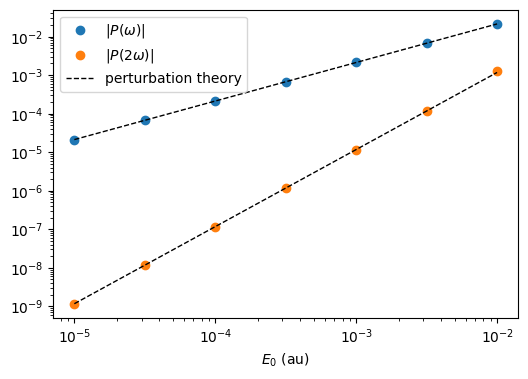

relative deviation of the second harmonic from the perturbative value:
[-0.0001 -0.     -0.      0.0001  0.0005  0.0053  0.0612]


In [6]:
osc2 = AnharmonicOscillator(omega0=0.5, gamma=0.01, a=0.5)
E0 = np.logspace(-5, -2, 7)
time = np.arange(0, 2000, 0.25)
pol = osc2.solve(time, lambda t: E0*np.sin(w0*t), substeps=4)

steady = time > 12/osc2.gamma
P = np.array([[fit_sum_frequencies(time[steady], p[steady], {1: w0, 2: 2*w0})[0][n]['A']/2 for n in (1, 2)] for p in pol])
P1 = np.abs(osc2.chi1(w0))*E0/2
P2 = np.abs(osc2.chi2(w0, w0))*(E0/2)**2

plt.figure(figsize=(6, 4))
plt.loglog(E0, P[:, 0], 'o', label=r'$|P(\omega)|$')
plt.loglog(E0, P1, 'k--', lw=1)
plt.loglog(E0, P[:, 1], 'o', label=r'$|P(2\omega)|$')
plt.loglog(E0, P2, 'k--', lw=1, label='perturbation theory')
plt.xlabel('$E_0$ (au)')
plt.legend()
plt.show()
print('relative deviation of the second harmonic from the perturbative value:')
print(np.round(P[:, 1]/P2-1, 4))